In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import VotingClassifier



In [3]:
# wczytanie danych
X_train = pd.read_csv("artifical_train_data.csv")
y_train = pd.read_csv("artifical_train_labels.csv")
X_test = pd.read_csv("artifical_test_data.csv")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

print("\nPierwsze wiersze X_train:")
print(X_train.head())

# zamiana 2 na 0 zeby potem nie zapomniec 
y_train = y_train.replace({2: 0})

print("\nPierwsze wiersze y_train:")
print(y_train.head())

# nie mamy y_test wiec musimy zrobic wlasny zbior do testowania

X_train shape: (1500, 100)
y_train shape: (1500, 1)
X_test shape: (500, 100)

Pierwsze wiersze X_train:
    V1   V2   V3   V4   V5   V6   V7   V8   V9  V10  ...  V91  V92  V93  V94  \
0  500  441  400  445  519  447  479  484  549  424  ...  436  477  496  458   
1  535  454  513  437  502  471  506  490  371  441  ...  519  484  500  460   
2  473  469  527  487  478  461  454  438  419  532  ...  537  492  467  480   
3  490  480  518  453  487  468  454  473  533  536  ...  518  487  485  457   
4  443  472  504  511  481  487  497  469  416  559  ...  511  472  483  502   

   V95  V96  V97  V98  V99  V100  
0  454  526  563  448  518   454  
1  493  497  489  462  489   500  
2  449  474  481  464  463   523  
3  460  465  445  468  511   470  
4  481  514  513  483  474   530  

[5 rows x 100 columns]

Pierwsze wiersze y_train:
   Class
0      0
1      1
2      1
3      1
4      1


In [4]:
n_nan_train = np.isnan(X_train.values).sum()
n_inf_train = np.isinf(X_train.values).sum()

print("X_train:")
print("Liczba NaN:", n_nan_train)
print("Liczba inf / -inf:", n_inf_train)

X_train:
Liczba NaN: 0
Liczba inf / -inf: 0


In [5]:
n_nan_test = np.isnan(X_test.values).sum()
n_inf_test = np.isinf(X_test.values).sum()

print("\nX_test:")
print("Liczba NaN:", n_nan_test)
print("Liczba inf / -inf:", n_inf_test)


X_test:
Liczba NaN: 0
Liczba inf / -inf: 0


wow nawet nie trzeba imputowac

In [6]:
y_train.value_counts()

Class
1        755
0        745
Name: count, dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# od razu przeskalowane do wszystkich modeli
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# elastic net

logreg_en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=4000,
    random_state=42
)

param_grid = {
    'C': np.concatenate([
        np.logspace(-4, -2, 10),
        np.logspace(-2, 0, 15),
        np.logspace(0, 1.3, 8)
    ]),
    
    'l1_ratio': np.concatenate([
        np.linspace(0.01, 0.2, 6),
        np.linspace(0.2, 0.8, 9),
        np.linspace(0.8, 0.99, 6)
    ])
}

grid = GridSearchCV(
    logreg_en,
    param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("Najlepsze parametry:", grid.best_params_)

# bedziemy kierowac sie metryka balanced accuracy
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

print(f"Balanced Accuracy - train: {balanced_accuracy_score(y_train, y_train_pred):.4f}")
print(f"Balanced Accuracy - test:  {balanced_accuracy_score(y_test, y_test_pred):.4f}")

Fitting 5 folds for each of 693 candidates, totalling 3465 fits
Najlepsze parametry: {'C': 0.019306977288832496, 'l1_ratio': 0.952}
Balanced Accuracy – train: 0.6108
Balanced Accuracy – test:  0.6163


c:\Users\misie\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# 'zwykla' regresja L1 (bo elasticnet zdecydowanie preferowal L1)

logreg = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=2000,
    random_state=42
)

param_grid = {
    'C': np.concatenate([
        np.logspace(-2.3, -0.5, 20),
        np.logspace(-3, 0, 10)
    ])
}

grid = GridSearchCV(
    logreg,
    param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print("Najlepszy parametr C:", grid.best_params_)


y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy - train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy - test:  {bal_acc_test:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Najlepszy parametr C: {'C': 0.021544346900318832}
Balanced Accuracy – train: 0.6101
Balanced Accuracy – test:  0.6197


c:\Users\misie\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
random_state = 42

# extra trees
etc = ExtraTreesClassifier(random_state=random_state)

param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 0.8]
}

grid = GridSearchCV(
    estimator=etc,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_etc = grid.best_estimator_
print("Najlepsze parametry:", grid.best_params_)

y_train_pred = best_etc.predict(X_train_scaled)
y_test_pred = best_etc.predict(X_test_scaled)

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy - train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy - test:  {bal_acc_test:.4f}")


Fitting 5 folds for each of 720 candidates, totalling 3600 fits


c:\Users\misie\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\misie\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Najlepsze parametry: {'max_depth': 20, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Balanced Accuracy – train: 1.0000
Balanced Accuracy – test:  0.8564


In [ ]:
# random forest
rf = RandomForestClassifier(random_state=random_state)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_rf = grid.best_estimator_
print("Najlepsze parametry:", grid.best_params_)

y_train_pred = best_rf.predict(X_train_scaled)
y_test_pred = best_rf.predict(X_test_scaled)

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy - train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy - test:  {bal_acc_test:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


c:\Users\misie\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Najlepsze parametry: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Balanced Accuracy – train: 1.0000
Balanced Accuracy – test:  0.8332


In [ ]:
# xgboost
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=random_state,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_xgb = grid.best_estimator_
print("Najlepsze parametry:", grid.best_params_)

y_train_pred = best_xgb.predict(X_train_scaled)
y_test_pred = best_xgb.predict(X_test_scaled)

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy - train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy - test:  {bal_acc_test:.4f}")

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


c:\Users\misie\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:12:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Najlepsze parametry: {'colsample_bytree': 1.0, 'gamma': 0.3, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.6}
Balanced Accuracy – train: 1.0000
Balanced Accuracy – test:  0.8500


In [ ]:
# svm
svm_model = SVC(random_state=random_state, probability=True)

param_grid = {
    'C': np.logspace(-2, 2, 10),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_svm = grid.best_estimator_
print("Najlepsze parametry:", grid.best_params_)

y_train_pred = best_svm.predict(X_train_scaled)
y_test_pred = best_svm.predict(X_test_scaled)

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy - train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy - test:  {bal_acc_test:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\misie\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Najlepsze parametry: {'C': 12.915496650148826, 'gamma': 'scale', 'kernel': 'rbf'}
Balanced Accuracy – train: 0.9325
Balanced Accuracy – test:  0.8398


In [ ]:
# k nearest neighbours
knn = KNeighborsClassifier()

param_grid = [
    {'n_neighbors': list(range(1, 50, 2)),
     'weights': ['uniform', 'distance'],
     'metric': ['minkowski'],
     'p': [1,2,3,4,5]},
    {'n_neighbors': list(range(1, 50, 2)),
     'weights': ['uniform', 'distance'],
     'metric': ['chebyshev', 'manhattan', 'euclidean']}
]

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train.to_numpy().ravel())

best_knn = grid.best_estimator_
print("Najlepsze parametry:", grid.best_params_)

y_train_pred = best_knn.predict(X_train_scaled)
y_test_pred = best_knn.predict(X_test_scaled)

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy - train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy - test:  {bal_acc_test:.4f}")

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Najlepsze parametry: {'metric': 'minkowski', 'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Balanced Accuracy – train: 1.0000
Balanced Accuracy – test:  0.8698


In [ ]:
# naiwny bayes
gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train.to_numpy().ravel())

y_train_pred = gnb.predict(X_train_scaled)
y_test_pred = gnb.predict(X_test_scaled)

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy - train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy - test:  {bal_acc_test:.4f}")

Balanced Accuracy – train: 0.6009
Balanced Accuracy – test:  0.6264


In [9]:
# AAAAAAAAAAAAAAAAAAAAAA NIE PONAZYWALEM WYNIKOW I MUSZE ROBIC KAZDY MODEL JESZCZE RAZ ZEBY TEGO ZNOWU NIE LICZYC GRIDSEARCHU
# troche bez sensu ale lepsze to niz czekac 30 min

random_state = 42
results = []

# Logistic L1
logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.021544346900318832, max_iter=2000, random_state=random_state)
logreg_l1.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = logreg_l1.predict(X_train_scaled)
y_test_pred  = logreg_l1.predict(X_test_scaled)
results.append({
    'model': 'Logistic L1',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# Logistic ElasticNet
logreg_en = LogisticRegression(penalty='elasticnet', solver='saga', C=0.019306977288832496,
                               l1_ratio=0.952, max_iter=3000, random_state=random_state)
logreg_en.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = logreg_en.predict(X_train_scaled)
y_test_pred  = logreg_en.predict(X_test_scaled)
results.append({
    'model': 'Logistic EN',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# ExtraTrees
et = ExtraTreesClassifier(n_estimators=300, max_depth=20, max_features=0.8,
                          min_samples_split=2, min_samples_leaf=1, random_state=random_state)
et.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = et.predict(X_train_scaled)
y_test_pred  = et.predict(X_test_scaled)
results.append({
    'model': 'ExtraTrees',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=None, max_features=0.5,
                            min_samples_split=2, min_samples_leaf=1, random_state=random_state)
rf.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = rf.predict(X_train_scaled)
y_test_pred  = rf.predict(X_test_scaled)
results.append({
    'model': 'Random Forest',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# XGBoost
xgb_classifier = xgb.XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.1, gamma=0.3,
                    colsample_bytree=1.0, subsample=0.6, use_label_encoder=False,
                    eval_metric='logloss', random_state=random_state)
xgb_classifier.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = xgb_classifier.predict(X_train_scaled)
y_test_pred  = xgb_classifier.predict(X_test_scaled)
results.append({
    'model': 'XGBoost',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# SVM
svm = SVC(C=12.915496650148826, kernel='rbf', gamma='scale', probability=True, random_state=random_state)
svm.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = svm.predict(X_train_scaled)
y_test_pred  = svm.predict(X_test_scaled)
results.append({
    'model': 'SVM',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# kNN
knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2, weights='distance')
knn.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = knn.predict(X_train_scaled)
y_test_pred  = knn.predict(X_test_scaled)
results.append({
    'model': 'kNN',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train.to_numpy().ravel())
y_train_pred = gnb.predict(X_train_scaled)
y_test_pred  = gnb.predict(X_test_scaled)
results.append({
    'model': 'GaussianNB',
    'bal_acc_train': balanced_accuracy_score(y_train, y_train_pred),
    'bal_acc_test': balanced_accuracy_score(y_test, y_test_pred)
})

# Dataframe z roznica balanced accuracy miedzy train a test
df_results = pd.DataFrame(results)
df_results['overfit_gap'] = df_results['bal_acc_train'] - df_results['bal_acc_test']
df_results = df_results.sort_values(by='bal_acc_test', ascending=False).reset_index(drop=True)

print(df_results)

c:\Users\misie\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:24:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


           model  bal_acc_train  bal_acc_test  overfit_gap
0     ExtraTrees       1.000000      0.849749     0.150251
1  Random Forest       1.000000      0.810014     0.189986
2        XGBoost       1.000000      0.756500     0.243500
3            SVM       1.000000      0.693320     0.306680
4            kNN       1.000000      0.642584     0.357416
5    Logistic L1       0.614266      0.629695    -0.015428
6    Logistic EN       0.611661      0.619628    -0.007967
7     GaussianNB       0.636134      0.616805     0.019329


In [11]:
# jeszcze jeden model voting_ensemble z 3 najlepiej działających modeli

xgb_final = xgb.XGBClassifier(
    n_estimators=300, max_depth=10, learning_rate=0.1, gamma=0.3,
    colsample_bytree=1.0, subsample=0.6, use_label_encoder=False,
    eval_metric='logloss', random_state=42
)

et_final = ExtraTreesClassifier(
    n_estimators=300, max_depth=20, max_features=0.8,
    min_samples_split=2, min_samples_leaf=1, random_state=42
)

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features=0.5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


voting_ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_final),
        ('et', et_final),
        ('rf', rf_final)
    ],
    voting='soft',
    n_jobs=-1
)

voting_ensemble.fit(X_train_scaled, y_train.to_numpy().ravel())

y_train_pred = voting_ensemble.predict(X_train_scaled)
y_test_pred  = voting_ensemble.predict(X_test_scaled)

y_test_proba = voting_ensemble.predict_proba(X_test_scaled)[:, 1]

bal_acc_train = balanced_accuracy_score(y_train, y_train_pred)
bal_acc_test  = balanced_accuracy_score(y_test, y_test_pred)

print(f"Balanced Accuracy – train: {bal_acc_train:.4f}")
print(f"Balanced Accuracy – test:  {bal_acc_test:.4f}")

Balanced Accuracy – train: 1.0000
Balanced Accuracy – test:  0.8267


In [12]:
# i dodajemy w analogiczny sposob do ramki danych wyników

overfit_gap  = bal_acc_train - bal_acc_test

voting_row = pd.DataFrame([{
    'model': 'Voting Ensemble',
    'bal_acc_train': bal_acc_train,
    'bal_acc_test': bal_acc_test,
    'overfit_gap': overfit_gap
}])

df_results = pd.concat([df_results, voting_row], ignore_index=True)



# sortujemy i wyswietlamy
df_results = df_results.sort_values(by='bal_acc_test', ascending=False).reset_index(drop=True)
print(df_results)

             model  bal_acc_train  bal_acc_test  overfit_gap
0       ExtraTrees       1.000000      0.849749     0.150251
1  Voting Ensemble       1.000000      0.826748     0.173252
2    Random Forest       1.000000      0.810014     0.189986
3          XGBoost       1.000000      0.756500     0.243500
4              SVM       1.000000      0.693320     0.306680
5              kNN       1.000000      0.642584     0.357416
6      Logistic L1       0.614266      0.629695    -0.015428
7      Logistic EN       0.611661      0.619628    -0.007967
8       GaussianNB       0.636134      0.616805     0.019329


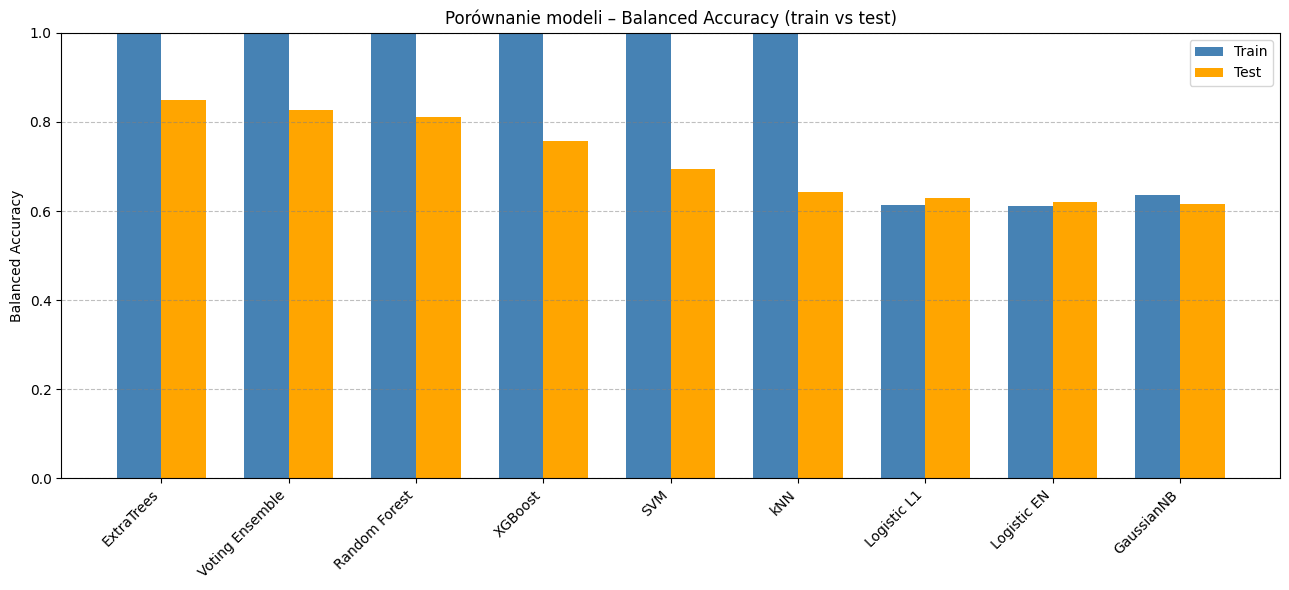

In [13]:
import matplotlib.pyplot as plt

models = df_results['model']
bal_acc_train = df_results['bal_acc_train']
bal_acc_test = df_results['bal_acc_test']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(13,6))

ax.bar(x - width/2, bal_acc_train, 0.35, label='Train', color='steelblue')
ax.bar(x + width/2, bal_acc_test,  width, label='Test',  color='orange')

ax.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

ax.set_ylabel('Balanced Accuracy')
ax.set_title('Porównanie modeli – Balanced Accuracy (train vs test)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# finalna predykcja do pliku 
# model extra trees wytrenowany na calym zbiorze danych

X_train = pd.read_csv("artifical_train_data.csv")
y_train = pd.read_csv("artifical_train_labels.csv")
X_test = pd.read_csv("artifical_test_data.csv")

y_train = y_train.replace({2: 0})

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

et_final = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=20,
    max_features=0.8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

et_final.fit(X_train_scaled, y_train.to_numpy().ravel())

y_test_proba = et_final.predict_proba(X_test_scaled)[:, 1]

output_file = "333092_artifical_prediction.txt"
pd.Series(y_test_proba).to_csv(output_file, index=False, header=False)

print(f"Prawdopodobieństwa zapisane do pliku: {output_file}")

Prawdopodobieństwa zapisane do pliku: 333092_artifical_prediction.txt
